<a href="https://www.kaggle.com/code/dozeradi007/cnn-digit-recognition?scriptVersionId=334805353" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.models import Model
from keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten
from keras.callbacks import EarlyStopping

## Load Dataset

In [2]:
((X_train, y_train),(X_test, y_test))=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Checking shape
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


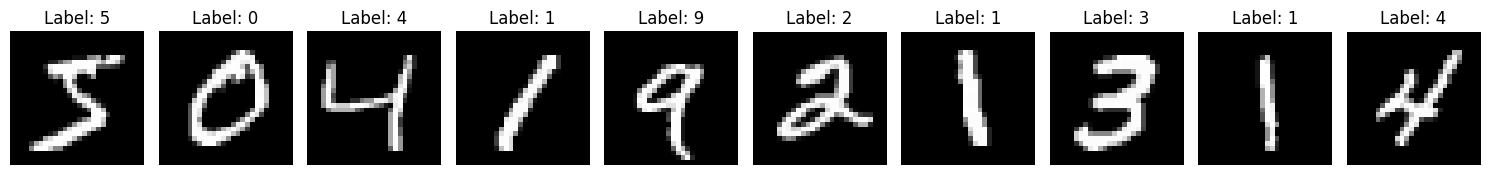

In [4]:
# visualize the data
fig, ax=plt.subplots(1,10, figsize=(15, 2))
for i in range(10):
    ax[i].imshow(X_train[i], cmap="grey")
    ax[i].set_title(f"Label: {y_train[i]}")
    ax[i].axis("off")
plt.tight_layout()
plt.show()

## Data Preprocessing

### Normalization

In [5]:
X_train=X_train/255
X_test=X_test/255

### Reshaping
- A CNN expects its input to have a **channel dimension** in addition to the image height and width.
- For datasets like **MNIST**, 1 colour channel is sufficient, but for images like **RGB**, they require <u>3 different channels per colour</u>.
- For coloured images (like RGB), the reshape would be like (28, 28, 3).

In [6]:
# -1 tells NumPy to infer the number of images automatically
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

## Defining the Architecture of CNN Models

In [7]:
# defining early stopping strategy
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=5,  # Number of epochs to wait for improvement before stopping
    restore_best_weights=True, # Roll back model weights to the best epoch
    start_from_epoch=5 #  Number of epochs to wait before starting to monitor improvement
)

### Model1 

In [8]:
model1=Sequential()

model1.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(28,28,1), activation='relu')) #gen activation map per filter
model1.add(MaxPool2D(pool_size=(2,2)))
model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
# model1.add(Dropout=0.5)
model1.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783947884.893871      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model1.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [11]:
hist_model1=model1.fit(X_train,y_train,batch_size=32,epochs=20,
                       verbose=1,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
  71/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6001 - loss: 1.2484

I0000 00:00:1783947889.183480      68 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9545 - loss: 0.1531 - val_accuracy: 0.9786 - val_loss: 0.0708
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9837 - loss: 0.0545 - val_accuracy: 0.9833 - val_loss: 0.0568
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9895 - loss: 0.0338 - val_accuracy: 0.9861 - val_loss: 0.0501
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9926 - loss: 0.0232 - val_accuracy: 0.9828 - val_loss: 0.0560
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9945 - loss: 0.0167 - val_accuracy: 0.9863 - val_loss: 0.0488
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9960 - loss: 0.0115 - val_accuracy: 0.9815 - val_loss: 0.0632
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9976 - loss: 0.0074 - val_accuracy: 0.9877 - val_loss: 0.0504
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9977 - loss: 0.0073 - val_accurac

In [12]:
losses_model1=pd.DataFrame(model1.history.history)
losses_model1

,accuracy,loss,val_accuracy,val_loss
0,0.954479,0.153140,0.978583,0.070819
1,0.983708,0.054462,0.983333,0.056840
2,0.989500,0.033791,0.986083,0.050089
3,0.992583,0.023219,0.982833,0.056026
4,0.994458,0.016731,0.986333,0.048792
5,0.995958,0.011507,0.981500,0.063212
6,0.997625,0.007390,0.987667,0.050356
7,0.997750,0.007320,0.987833,0.051517
8,0.997979,0.006026,0.985667,0.068082
9,0.998729,0.004043,0.986083,0.063831


### Model2

In [13]:
model2=Sequential()

model2.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(28,28,1), activation='relu')) #gen activation map per filter
model2.add(MaxPool2D(pool_size=(2,2)))
model2.add(Conv2D(filters=64, kernel_size=(4,4), activation='relu')) #find more complex features
model2.add(MaxPool2D(pool_size=(2,2)))
model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
# model2.add(Dropout=0.5)
model2.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,866 (647.91 KB)

 Trainable params: 165,866 (647.91 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model2.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [16]:
hist_model2=model2.fit(X_train,y_train,batch_size=32,epochs=20,
                       verbose=1,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9519 - loss: 0.1533 - val_accuracy: 0.9787 - val_loss: 0.0669
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0482 - val_accuracy: 0.9869 - val_loss: 0.0449
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0329 - val_accuracy: 0.9893 - val_loss: 0.0332
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9922 - loss: 0.0247 - val_accuracy: 0.9882 - val_loss: 0.0370
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9944 - loss: 0.0174 - val_accuracy: 0.9896 - val_loss: 0.0384
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9950 - loss: 0.0152 - val_accuracy: 0.9872 - val_loss: 0.0480
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9956 - loss: 0.0126 - val_accuracy: 0.9880 - val_loss: 0.0454
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9973 - loss: 0.0085 - 

In [17]:
losses_model2=pd.DataFrame(model2.history.history)
losses_model2

,accuracy,loss,val_accuracy,val_loss
0,0.951854,0.153262,0.978750,0.066880
1,0.985750,0.048177,0.986917,0.044860
2,0.989229,0.032910,0.989333,0.033182
3,0.992167,0.024677,0.988167,0.036960
4,0.994438,0.017449,0.989583,0.038405
5,0.995042,0.015204,0.987250,0.047985
6,0.995562,0.012605,0.988000,0.045370
7,0.997312,0.008491,0.987500,0.054513
8,0.997229,0.008357,0.989000,0.056959
9,0.997583,0.007557,0.989750,0.053052


## Evaluating models

In [18]:
ann_model=keras.models.load_model("/kaggle/input/notebooks/dozeradi007/handwritten-digit-recognition/model4.keras")
hist_ann_model=pd.read_csv("/kaggle/input/notebooks/dozeradi007/handwritten-digit-recognition/model4_history.csv")

In [19]:
test_hist_ann=ann_model.evaluate(X_test,y_test,verbose=1,return_dict=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9712 - loss: 0.1458


In [20]:
test_hist_cnn1=model1.evaluate(X_test,y_test,verbose=1,return_dict=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9885 - loss: 0.0483


In [21]:
test_hist_cnn2=model2.evaluate(X_test,y_test,verbose=1,return_dict=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9894 - loss: 0.0344


### Storing Predictions

In [22]:
ann_predict=ann_model.predict(X_test)
ann_predict_classes=np.argmax(ann_predict, axis=1)

ann_predict_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [23]:
cnn1_predict=model1.predict(X_test)
cnn1_predict_classes=np.argmax(cnn1_predict, axis=1)
cnn1_predict_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [24]:
cnn2_predict=model2.predict(X_test)
cnn2_predict_classes=np.argmax(cnn2_predict, axis=1)
cnn2_predict_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [25]:
histories = {
    "ANN model": hist_ann_model,
    "CNN model1": hist_model1.history,
    "CNN model2": hist_model2.history
}

### Building comparison_table and wrong_pred_digits

In [26]:
predictions = {
    "ANN": ann_predict_classes,
    "CNN1": cnn1_predict_classes,
    "CNN2": cnn2_predict_classes
}

wrong_preds = {}

for name, preds in predictions.items():
    counts = {}
    total=0
    for true, pred in zip(y_test, preds):
        if pred != true:
            counts[true] = counts.get(true, 0) + 1
            total+=1

    counts = dict(sorted(counts.items()))
    counts["total"] = total
    wrong_preds[name] = counts

comparison_table=pd.DataFrame({
    "Metric":  ["ANN model","CNN model1","CNN model2"],
    "Test Accuracy": [test_hist_ann['accuracy'], test_hist_cnn1['accuracy'], test_hist_cnn2['accuracy']],
    "Test Loss": [test_hist_ann['loss'], test_hist_cnn1['loss'], test_hist_cnn2['loss']],
    "Wrong predictions": [wrong_preds[key]['total'] for key in predictions],
    "Parameters": [ann_model.count_params(), model1.count_params(), model2.count_params()],
    "Best Validation Accuracy": [max(history['val_accuracy']) for k, history in histories.items()],
    "Completed epoches": [len(history['loss']) for k, history in histories.items()]
})

In [27]:
comparison_table

,Metric,Test Accuracy,Test Loss,Wrong predictions,Parameters,Best Validation Accuracy,Completed epoches
0,ANN model,0.9712,0.145755,288,55050,0.976167,20
1,CNN model1,0.9885,0.048346,115,591786,0.987833,12
2,CNN model2,0.9894,0.034404,106,165866,0.989750,12


In [28]:
wrong_pred_digits = pd.DataFrame({"Digit": range(10)})

for model_name in wrong_preds:
    wrong_pred_digits[model_name] = [
        wrong_preds[model_name].get(i, 0) for i in range(10)
    ]

wrong_pred_digits.reset_index(drop=True, inplace=True)

In [29]:
wrong_pred_digits

,Digit,ANN,CNN1,CNN2
0,0,9,3,3
1,1,15,3,9
2,2,35,16,4
3,3,6,14,9
4,4,26,11,22
5,5,46,9,5
6,6,22,13,6
7,7,32,10,29
8,8,50,17,7
9,9,47,19,12


- by observing above `wrong_pred_digits` table, we can find the most confusing numbers for all models

## Saving best models

In [30]:
model2.save("cnn_model2.keras")
print("model2 is saved as 'cnn_model2.kears'")
# saving training history
pd.DataFrame(hist_model2.history).to_csv("cnn_model2_history.csv", index=False)
print("cnn_model2 history is stored")

model2 is saved as 'cnn_model2.kears'
cnn_model2 history is stored


## Learning curve of all models including my ANN model

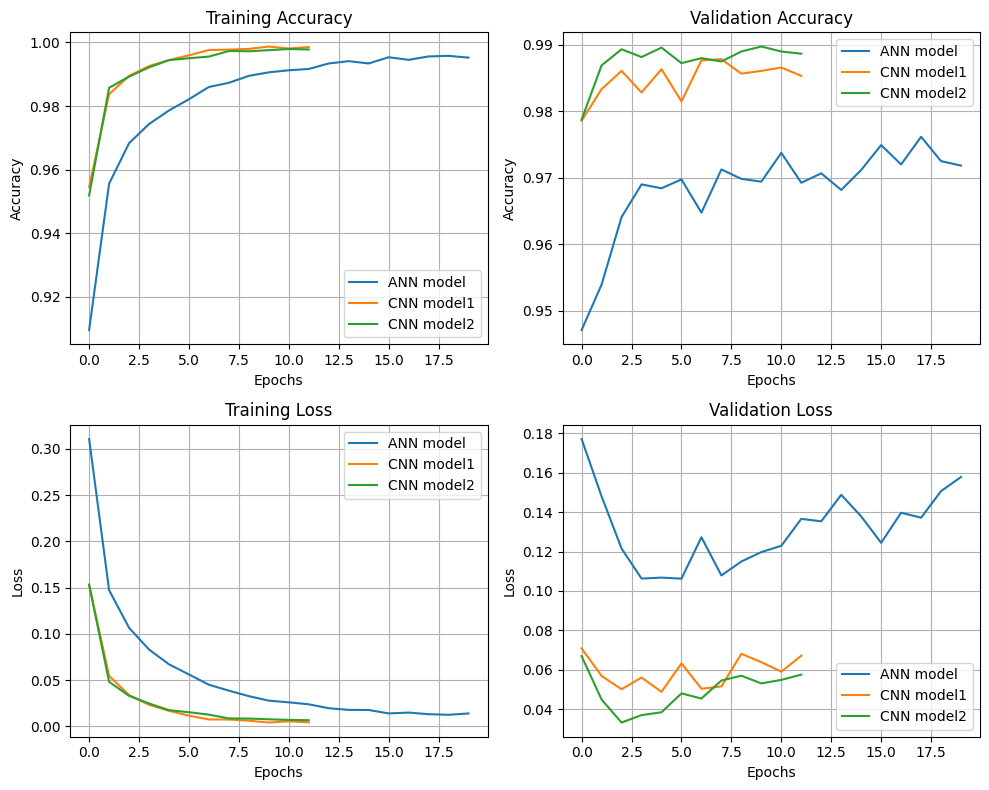

In [31]:
plots = [
    ("accuracy", "Training Accuracy", "Accuracy"),
    ("val_accuracy", "Validation Accuracy", "Accuracy"),
    ("loss", "Training Loss", "Loss"),
    ("val_loss", "Validation Loss", "Loss")
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (metric, title, ylabel) in zip(axes.flat, plots):
    for label, history in histories.items():
        ax.plot(history[metric], label=label)

    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

- Through the above plot, we can see the CNN model is outperforming the ANN model.
- The reason for shorter lines for CNN models is because I use `EarlyStopping()`, their architecture.
- In the **'Validation Loss'** plot, we can see the huge difference between the ANN and CNN models

## Confusion matrix of ANN and CNN model

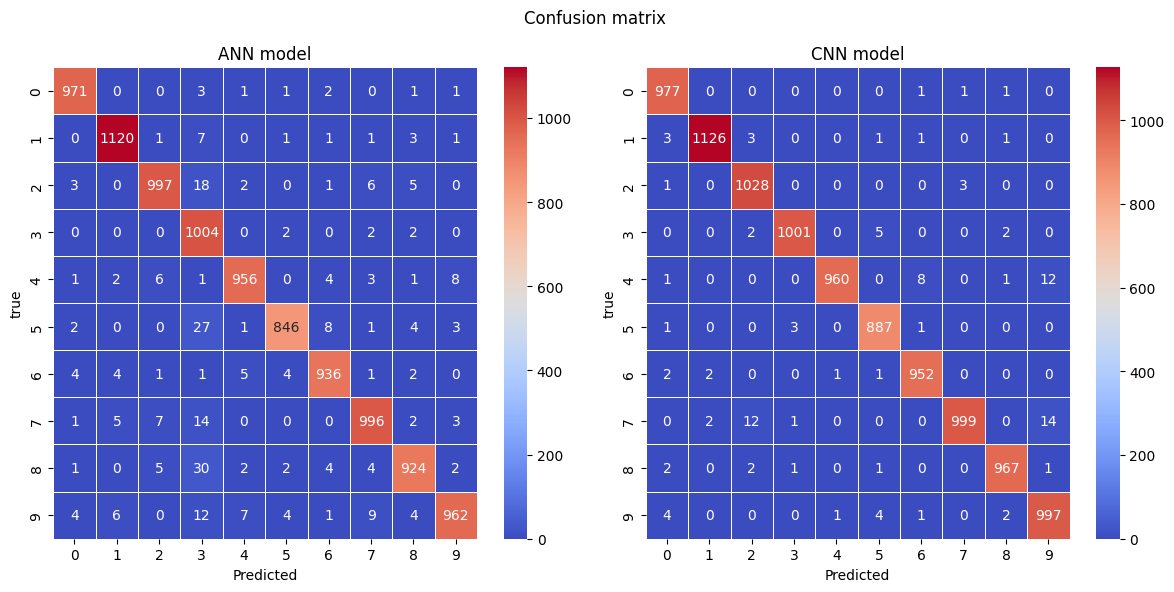

In [32]:
ann_cm=tensorflow.math.confusion_matrix(labels=y_test, predictions=ann_predict_classes, num_classes=10)
cnn_cm=tensorflow.math.confusion_matrix(labels=y_test, predictions=cnn2_predict_classes, num_classes=10)

fig, ax = plt.subplots(1,2, figsize=(12,6))

sns.heatmap(ann_cm, annot=True, fmt="d", cmap="coolwarm", linewidths=0.5, ax=ax[0])
ax[0].set_title("ANN model")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("true")

sns.heatmap(cnn_cm, annot=True, fmt="d", cmap="coolwarm", linewidths=0.5, ax=ax[1])
ax[1].set_title("CNN model")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("true")

plt.suptitle("Confusion matrix")
plt.tight_layout()
plt.show()

## Limitations
- MNIST is a simple dataset.
- Images are grayscale and centered.
- Results may not generalize to more complex datasets like CIFAR-10 or ImageNet.
- CNNs require more computation than ANNs.

## Future Scope
- Apply CNNs to CIFAR-10 (color images).
- Experiment with data augmentation.
- Investigate deeper architectures like ResNet.
- Transition from classification to image restoration tasks (e.g., super-resolution).

## To Do 
- Add a Feature Map Visualizations at each CNN layer

## Q/A

- Why use 32 filters?
    - 32 feature generations, 32 activation/feature maps; if we go for only 1 filter, then it captures only 1 feature. That's why we use a number of features which may capture different features.
    
- Why do later layers often have more filters?
    - The later layers are use to combine the features extracted by their previous layers.
    - As features become more complex, the network benefits from having more filters to represent a richer variety of patterns.
    - After each pooling layer, the spatial dimensions shrink.
    - Since each feature map becomes smaller, the computational cost per filter decreases. This makes it feasible to increase the number of filters while keeping the total computation manageable.

- kernel_size:
    - Also known as filter_size or receptive_field_size.
    - It represents the spatial dimensions (height and width) of the filter applied during a convolution operation.
    - These kernels are essentially matrices of learnable weights that glide across an input image or a previous feature map to detect specific visual features, such as edges, loops, or complex shapes like an eye
    - A kernel's depth will always extend through the entire depth of the input volume. For example, if you apply a 6x6 kernel to an RGB-coloured image, the kernel will have a depth of 3, meaning the neuron contains 108 individual weights (6x6x3)

- pool_size:
    - It defines the spatial dimensions of the window used to downsample a feature map within a pooling layer
    - Because pooling is highly destructive to the underlying data, utilizing a pool size larger than 3x3 will usually lead to a significant decrease in the model's performance

- Does I need to add dropout?
    - Dropout is a regularization technique that randomly "turns off" a fraction of neurons during training.
    - for `dropout(0.5)` about 50% of the neurons in that layer are randomly ignored during **each training step**. This forces the network to learn more robust features instead of relying too heavily on specific neurons.